In [ ]:
import torch
torch.cuda.is_available()

True

In [ ]:
!nvidia-smi

Sun Nov 16 14:42:08 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   51C    P8             10W /   70W |       2MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
!pip install diffusers transformers accelerate safetensors --upgrade
!pip install torch --index-url https://download.pytorch.org/whl/cu121

Looking in indexes: https://download.pytorch.org/whl/cu121


In [ ]:
from diffusers import DiffusionPipeline

print("Diffusers OK!")

Diffusers OK!


In [ ]:
from diffusers import StableDiffusionImg2ImgPipeline
import torch

In [ ]:
model_id = "runwayml/stable-diffusion-v1-5"

pipe = StableDiffusionImg2ImgPipeline.from_pretrained(
    model_id,
    torch_dtype=torch.float16,
    safety_checker=None
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Fetching 13 files:   0%|          | 0/13 [00:00<?, ?it/s]

scheduler_config.json:   0%|          | 0.00/308 [00:00<?, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

config.json:   0%|          | 0.00/547 [00:00<?, ?B/s]

vae/diffusion_pytorch_model.safetensors:   0%|          | 0.00/335M [00:00<?, ?B/s]

unet/diffusion_pytorch_model.safetensors:   0%|          | 0.00/3.44G [00:00<?, ?B/s]

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

`torch_dtype` is deprecated! Use `dtype` instead!
You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion_img2img.StableDiffusionImg2ImgPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .


In [ ]:
pipe = pipe.to("cuda")

In [ ]:
pipe.enable_attention_slicing()
print("SD 1.5 Img2Img pipeline готовий!")

SD 1.5 Img2Img pipeline готовий!


In [ ]:
from google.colab import drive
drive.mount('/content/drive')
from PIL import Image

def load_image(path):
    img = Image.open(path).convert("RGB")
    img = img.resize((512, 512))
    return img

base_path = "/content/drive/MyDrive/ColabNotebooks/Ntic_lab4/Data/"

img1 = load_image(base_path + "img1.jpg")   # чашка
img2 = load_image(base_path + "img2.jpg")   # портрет
img3 = load_image(base_path + "img3.jpg")   # будинки


Mounted at /content/drive


In [ ]:
prompt = "cyberpunk style"
negative_prompt = ""

baseline_seed = 42
generator = torch.Generator("cuda").manual_seed(baseline_seed)

def generate_baseline(input_image, name):
    image = pipe(
        prompt=prompt,
        negative_prompt=negative_prompt,
        image=input_image,
        strength=0.65,
        guidance_scale=11,
        num_inference_steps=50,
        generator=generator
    ).images[0]

    image.save(f"/content/{name}_baseline.png")
    return image
baseline1 = generate_baseline(img1, "img1")
baseline2 = generate_baseline(img2, "img2")
baseline3 = generate_baseline(img3, "img3")


  0%|          | 0/32 [00:00<?, ?it/s]

  0%|          | 0/32 [00:00<?, ?it/s]

  0%|          | 0/32 [00:00<?, ?it/s]

Baseline – чашка:


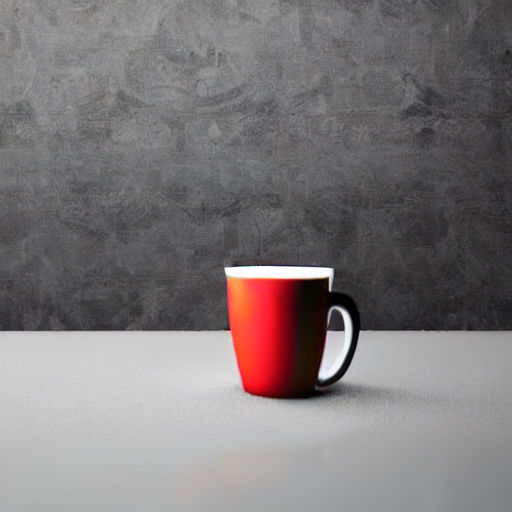

Baseline – портрет:


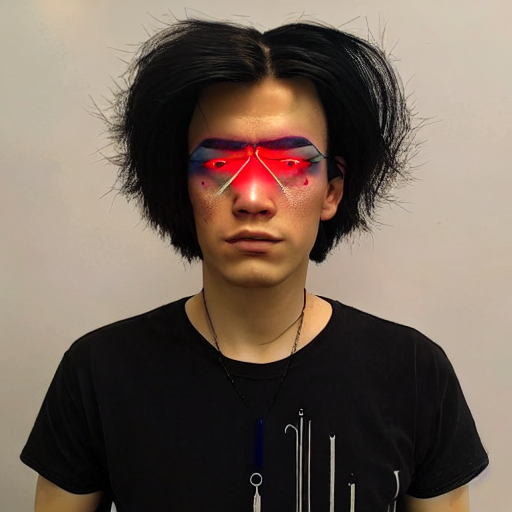

Baseline – пейзаж:


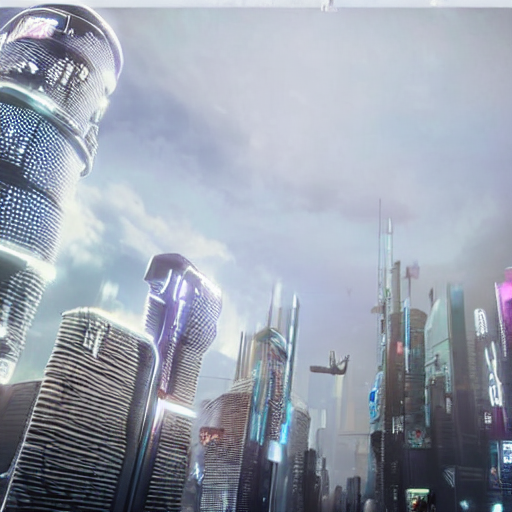

In [ ]:
from IPython.display import display

print("Baseline – чашка:")
display(baseline1)

print("Baseline – портрет:")
display(baseline2)

print("Baseline – пейзаж:")
display(baseline3)


In [ ]:
import os
save_dir = "/content/drive/MyDrive/ColabNotebooks/Ntic_lab4/Data/GeneralizedData/"
os.makedirs(save_dir, exist_ok=True)

baseline1.save(save_dir + "baseline_cup_cyberpank.jpg")
baseline2.save(save_dir + "baseline_portrait_cyberpank.jpg")
baseline3.save(save_dir + "baseline_landscape_cyberpank.jpg")


In [ ]:
import os
import torch
from IPython.display import display

prompt = "colorful, warm lighting, detailed, high quality photo, natural colors, realistic texture"
negative_prompt = ""
seed = 42
resolution = "512x512"

save_path = "/content/drive/MyDrive/ColabNotebooks/Ntic_lab4/Data/GeneralizedData/exp2/"
os.makedirs(save_path, exist_ok=True)

def generate_and_save(img, series, param_value, cfg, steps, strength):
    generator = torch.Generator("cuda").manual_seed(seed)

    result = pipe(
        prompt=prompt,
        negative_prompt=negative_prompt,
        image=img,
        strength=strength,
        guidance_scale=cfg,
        num_inference_steps=steps,
        generator=generator
    ).images[0]

    filename = (
        f"{series}"
        f"_strength-{strength}"
        f"_cfg-{cfg}"
        f"_steps-{steps}"
        f"_seed-{seed}"
        f"_sched-EulerA"
        f"_res-{resolution}.png"
    )

    filepath = os.path.join(save_path, filename)
    result.save(filepath)

    print("Збережено:", filepath)
    return result


# ========== СЕРІЯ 1: STRENGTH ==========
strength_values = [0.3, 0.6, 0.9]
series_name = "img1_strength"

print("=== Серія: STRENGTH ===")
strength_results = []

for s in strength_values:
    img = generate_and_save(
        img1,
        series=series_name,
        param_value=s,
        cfg=7.5,
        steps=30,
        strength=s
    )
    strength_results.append((s, img))


# ========== СЕРІЯ 2: CFG ==========
cfg_values = [5, 7.5, 10]
series_name_cfg = "img1_cfg"

print("\n=== Серія: CFG ===")
cfg_results = []

for cfg in cfg_values:
    img = generate_and_save(
        img1,
        series=series_name_cfg,
        param_value=cfg,
        cfg=cfg,
        steps=30,
        strength=0.6
    )
    cfg_results.append((cfg, img))


# ========== СЕРІЯ 3: STEPS ==========
steps_values = [20, 30, 50]
series_name_steps = "img1_steps"

print("\n=== Серія: STEPS ===")
steps_results = []

for st in steps_values:
    img = generate_and_save(
        img1,
        series=series_name_steps,
        param_value=st,
        cfg=7.5,
        steps=st,
        strength=0.6
    )
    steps_results.append((st, img))


print("\nУсі серії збережено успішно!")


=== Серія: STRENGTH ===


  0%|          | 0/9 [00:00<?, ?it/s]

Збережено: /content/drive/MyDrive/ColabNotebooks/Ntic_lab4/Data/GeneralizedData/exp2/img1_strength_strength-0.3_cfg-7.5_steps-30_seed-42_sched-EulerA_res-512x512.png


  0%|          | 0/18 [00:00<?, ?it/s]

Збережено: /content/drive/MyDrive/ColabNotebooks/Ntic_lab4/Data/GeneralizedData/exp2/img1_strength_strength-0.6_cfg-7.5_steps-30_seed-42_sched-EulerA_res-512x512.png


...

Збережено: /content/drive/MyDrive/ColabNotebooks/Ntic_lab4/Data/GeneralizedData/exp2/img1_steps_strength-0.6_cfg-7.5_steps-20_seed-42_sched-EulerA_res-512x512.png


  0%|          | 0/18 [00:00<?, ?it/s]

Збережено: /content/drive/MyDrive/ColabNotebooks/Ntic_lab4/Data/GeneralizedData/exp2/img1_steps_strength-0.6_cfg-7.5_steps-30_seed-42_sched-EulerA_res-512x512.png


  0%|          | 0/30 [00:00<?, ?it/s]

Збережено: /content/drive/MyDrive/ColabNotebooks/Ntic_lab4/Data/GeneralizedData/exp2/img1_steps_strength-0.6_cfg-7.5_steps-50_seed-42_sched-EulerA_res-512x512.png

Усі серії збережено успішно!


In [ ]:
import os
import torch
from IPython.display import display

prompt = "colorful, warm lighting, detailed, high quality photo, natural colors, realistic texture"
negative_prompt_good = "low quality, blur, artifacts, distorted, bad details"
seed = 42
resolution = "512x512"

save_path = "/content/drive/MyDrive/ColabNotebooks/Ntic_lab4/Data/GeneralizedData/exp4_negative_prompt/"
os.makedirs(save_path, exist_ok=True)

strength = 0.8
cfg = 7.5
steps = 50

def gen(img, negative_prompt, series_label):
    generator = torch.Generator("cuda").manual_seed(seed)

    out = pipe(
        prompt=prompt,
        negative_prompt=negative_prompt,
        image=img,
        strength=strength,
        guidance_scale=cfg,
        num_inference_steps=steps,
        generator=generator
    ).images[0]

    filename = (
        f"{series_label}"
        f"_strength-{strength}"
        f"_cfg-{cfg}"
        f"_steps-{steps}"
        f"_seed-{seed}"
        f"_res-{resolution}.png"
    )

    filepath = os.path.join(save_path, filename)
    out.save(filepath)
    print("Збережено:", filepath)

    return out

print("=== Без negative prompt ===")
img_no_neg = gen(img2, negative_prompt="", series_label="img2_no_negative")

print("\n=== З negative prompt ===")
img_with_neg = gen(img2, negative_prompt=negative_prompt_good, series_label="img2_with_negative")


=== Без negative prompt ===


  0%|          | 0/40 [00:00<?, ?it/s]

Збережено: /content/drive/MyDrive/ColabNotebooks/Ntic_lab4/Data/GeneralizedData/exp4_negative_prompt/img2_no_negative_strength-0.8_cfg-7.5_steps-50_seed-42_res-512x512.png

=== З negative prompt ===


  0%|          | 0/40 [00:00<?, ?it/s]

Збережено: /content/drive/MyDrive/ColabNotebooks/Ntic_lab4/Data/GeneralizedData/exp4_negative_prompt/img2_with_negative_strength-0.8_cfg-7.5_steps-50_seed-42_res-512x512.png
